# Load

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4
from qick_workspace.scrip.base_experiment import BaseExperiment
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

file_path = r'D:\Labber_Data\Jay\twpa'
BaseExperiment.setup(soc, soccfg, file_path)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a26a06964c834b27b9923f561f181a5d@192.168.10.82:41297
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

# qb setting

In [2]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# onetone check

c:\Users\cluster\Desktop\SQC_soc-main\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


abcd_rf_fit result:
 {'Fres(GHz)': np.float64(4.0945), 'Qi': 6, 'absQc': 1, 'Ql': 1, 'κ(MHz)': np.float64(4227.01)}
Data saved to D:\Labber_Data\Jay\twpa\2026\04\Data_0421\s002_onetone_ge_Q1_017


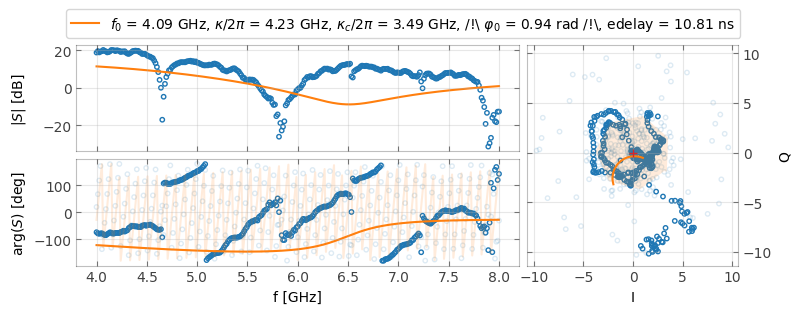

In [9]:
from qick_workspace.scrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
START_FREQ = 4000 # [MHz]
STOP_FREQ = 8000  # [MHz]


STEPS = 301

config_all.update("res.res_gain_ge", 0.02, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
result = onetone.run(py_avg=1, solve_type="hm")
## update value ##
config_all.update("res_freq_ge", round(result['Fres(GHz)']*1e3, 4), q_index=qubit)
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

# connect yoko

In [51]:
from qick_workspace.tools.YOKOGS200 import YOKOGS200
import pyvisa

rm = pyvisa.ResourceManager()
yoko_connect = "USB0::0x0B21::0x0039::91S522309::INSTR"
yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
yoko.OutputOff()

In [50]:
yoko.SetMode("current")
yoko.current_ramp_step = 10e-6
yoko.ramp_interval = 0.01
yokocurrent = 0.0* 1e-6
yoko.SetCurrent(yokocurrent)
yoko.GetValue()

Setting Current:   0%|          | 0/65 [00:00<?, ?it/s]

{'unit': 'A', 'value': 0.0}

# currwnt range

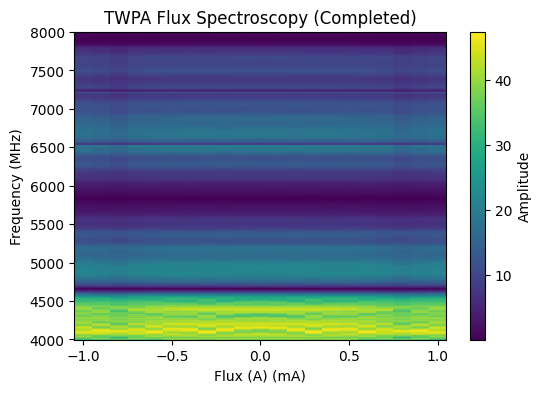

Data saved to D:\Labber_Data\Jay\twpa\2026\04\Data_0421\TWPA_flux_Q1_047


In [35]:
from qick_workspace.scrip.s002d_TWPA_flux import TWPAFlux


START_FREQ = 4000  # [MHz]
STOP_FREQ = 8000  # [MHz]
STEPS = 601

Start_flux = 1
Stop_flux = -1
Steps_flux = 21
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux) * 1e-3

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("res_gain_ge", 1),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
        ("yoko_range", yoko_range),
    ]
)

twpa = TWPAFlux(run_cfg)
###
twpa.YOKO_CURRENT_RAMP_STEP = 10e-6
twpa.YOKO_RAMP_INTERVAL = 0.01
###
twpa.run(
    3, yoko_inst=yoko_connect, yoko_value=yoko_range, yoko_mode="current"
)
twpa.saveLabber(qubit, config_all=config_all)

Peak-to-peak electrical length = 1.599 ns


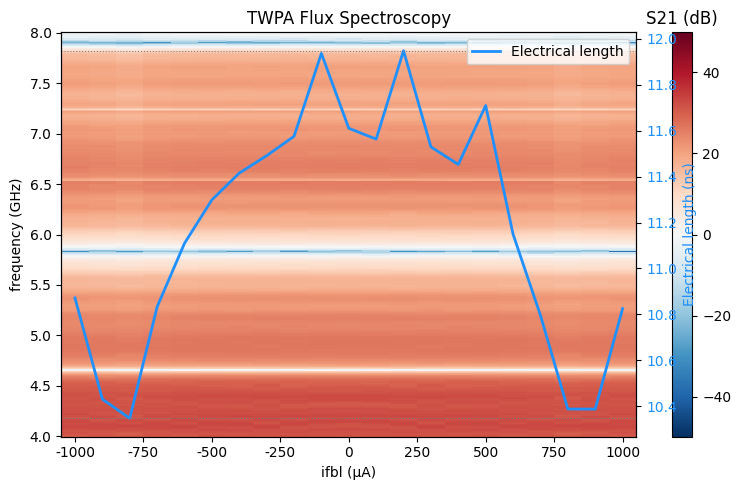

In [34]:
fig = twpa.plot()

In [4]:
from qick_workspace.scrip.s002e_TWPA_gain import TWPAGain
from qick_workspace.tools.mg3692 import AnritsuMG3692


pump = AnritsuMG3692("192.168.10.182")

Connected to: ANRITSU,MG3692C,192403,3.62


In [47]:
pump.frequency = 11.32e9
pump.output(True)
pump.power=20

In [49]:
pump.off()

# pump frequency

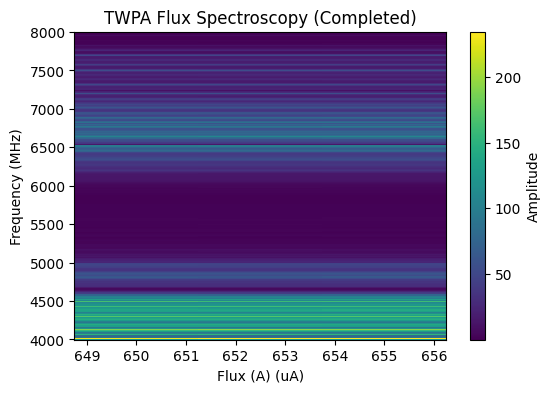

Data saved to D:\Labber_Data\Jay\twpa\2026\04\Data_0421\TWPA_flux_TWPA_pumpfreq_11.32GHz_power_+20.0dBm_010
Gain data saved to temp\2026\04\Data_0421\temp_gain.nc
Reference saved to temp\2026\04\Data_0421\temp_gain_reference.nc
[saved] 3/3 pump_freq steps → temp


In [39]:
from qick_workspace.scrip.s002e_TWPA_gain import TWPAGain
from qick_workspace.tools.mg3692 import AnritsuMG3692
from qick_workspace.scrip.s002d_TWPA_flux import TWPAFlux



START_FREQ = 4000  # [MHz]
STOP_FREQ = 8000  # [MHz]
STEPS = 501


Start_flux = 0.65
Stop_flux = 0.655
Steps_flux = 3
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux) * 1e-3

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("res_gain_ge", 0.4),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
        ("yoko_range", yoko_range),
    ]
)
# Step 1：量 unpumped reference（pump OFF）
ref = TWPAFlux(run_cfg)

ref.YOKO_CURRENT_RAMP_STEP = 10e-6
ref.YOKO_RAMP_INTERVAL = 0.01
pump.output(False)
print('Pump status: ', pump.output())
ref.run(1, yoko_inst=yoko_connect, yoko_value=yoko_range, yoko_mode="current")
ref.saveLabber(qubit, config_all=config_all, name="unpumped_ref")


PUMP_FREQS = np.linspace(11.31e9, 11.32e9, 3)
pump.output(True)
gain = TWPAGain(run_cfg, pump, pump_freqs=PUMP_FREQS, pump_power=20)
gain.YOKO_CURRENT_RAMP_STEP = 10e-6
gain.YOKO_RAMP_INTERVAL = 0.01

gain.run(1, yoko_inst=yoko_connect, yoko_value=yoko_range,
         temp_folder="temp",
         save_raw=True,
         reference=ref)


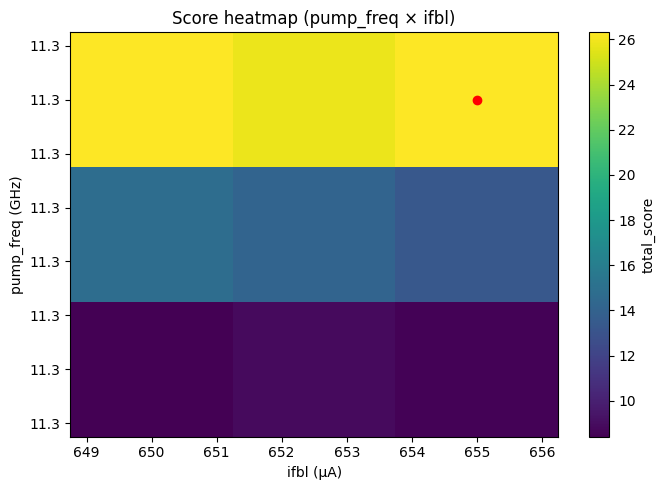

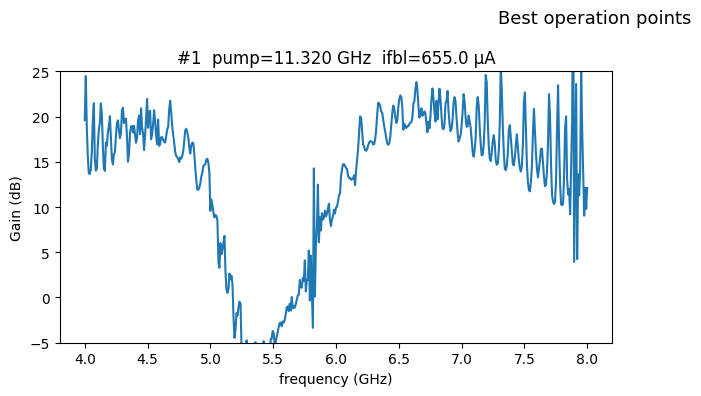


=== Best operation points ===
  #1  pump_freq = 11.3200 GHz  |  ifbl = 655.00 µA  |  score = 26.317


In [40]:
best, score = gain.analyze(
    reference=ref,
    gain_min=10,
    n_best=10
)

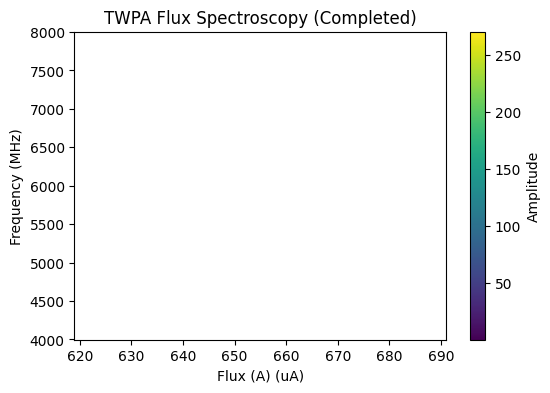

Power scan saved to temp\2026\04\Data_0421\temp_power_scan.nc
Reference saved to temp\2026\04\Data_0421\temp_power_scan_reference.nc
  [checkpoint] 7/7 powers saved
Power scan saved to temp\2026\04\Data_0421\temp_power_scan.nc
Reference saved to temp\2026\04\Data_0421\temp_power_scan_reference.nc
[final save] 7/7 power steps → temp


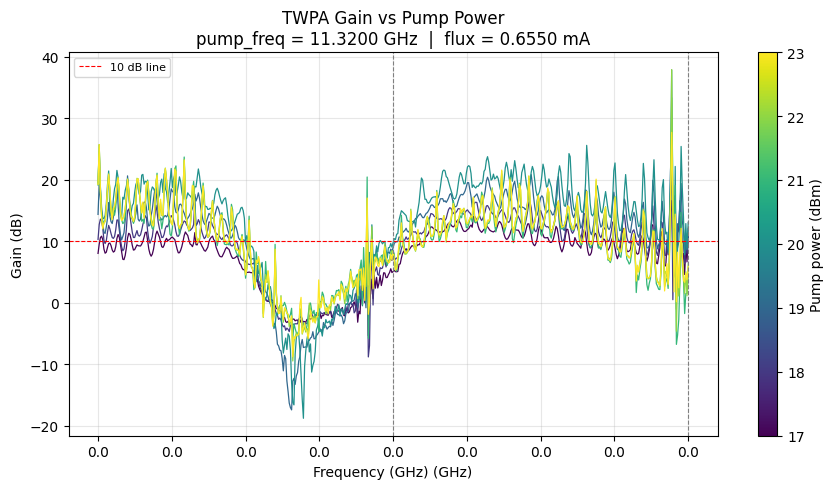


=== Gain summary  (pump_freq = 11.3200 GHz,  flux = 0.6550 mA) ===
   Power (dBm)   Peak gain (dB)   Median gain (dB)
--------------------------------------------------
          17.0            17.42              10.58
          18.0            22.03              12.68
          19.0            26.49              15.14
          20.0            37.88              17.88
          21.0            33.36              11.80
          22.0            37.95              12.17
          23.0            27.72              12.21


<xarray.DataArray (pump_power: 7, frequency: 501)> Size: 28kB
array([[ 8.03085279,  9.53382379, 10.59866417, ...,  9.17469277,
         6.63874928, 10.88945861],
       [10.31892413, 12.72739813, 13.60862213, ..., 10.2136849 ,
         8.05227678, 10.79973173],
       [14.37677052, 19.30688899, 17.01752338, ..., 11.25455056,
         8.82672522, 12.09245879],
       ...,
       [19.15666868, 25.71725723, 18.35533801, ...,  1.50165351,
         1.5167144 ,  4.61227193],
       [19.34013676, 25.72116986, 18.31775968, ...,  5.05263378,
         1.13161012,  6.35675925],
       [19.26371975, 25.74286566, 18.20185987, ...,  4.82541401,
         3.73512603,  5.83423453]])
Coordinates:
  * frequency   (frequency) float64 4kB 4e+09 4.008e+09 ... 7.992e+09 8e+09
  * pump_power  (pump_power) float64 56B 17.0 18.0 19.0 20.0 21.0 22.0 23.0

In [46]:
from qick_workspace.scrip.s002g_TWPA_power_scan import TWPAPowerScan

PUMP_FREQ  = 11.32e9          # Hz — fixed
FLUX_VALUE = 0.655e-3         # A  — fixed (pick one from yoko_range)
PUMP_POWERS = np.arange(17, 24, 1)   # dBm, adjust range as needed

scan = TWPAPowerScan(run_cfg, pump, pump_freq=PUMP_FREQ,
                     pump_powers=PUMP_POWERS, flux_value=FLUX_VALUE)
scan.YOKO_CURRENT_RAMP_STEP = 10e-6
scan.YOKO_RAMP_INTERVAL = 0.01

pump.output(True)
scan.run(1, yoko_inst=yoko_connect, yoko_mode="current",
         temp_folder="temp", reference=ref)

scan.analyze(reference=ref, f_min=6e9, f_max=8e9)

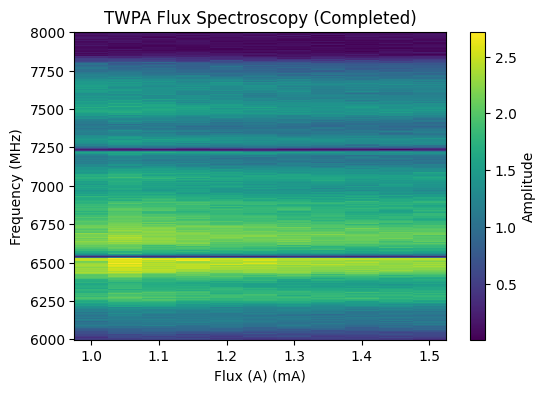

Data saved to D:\Labber_Data\Jay\twpa\2026\04\Data_0421\TWPA_flux_TWPA_power_+28.0dBm_pumpfreq_11.400GHz_001
    pump_freq = 11.6000 GHz
Yoko sweep mode: current | unit: mA | V_step: 1.00e-05 V  I_step: 1.00e-05 A  interval: 10.0 ms


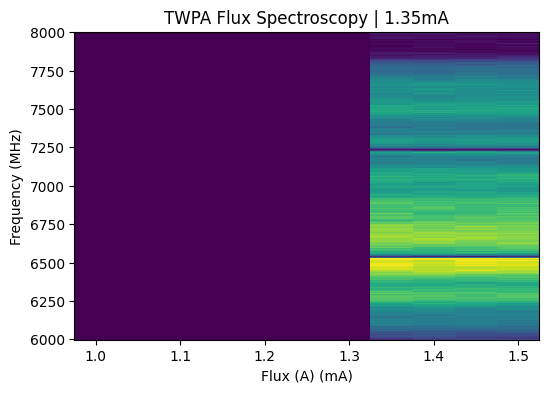

Sweeping current (Plot X-axis):   0%|          | 0/11 [00:00<?, ?it/s]

Setting Current:   0%|          | 0/50 [00:00<?, ?it/s]

Setting Current:   0%|          | 0/5 [00:00<?, ?it/s]

Setting Current:   0%|          | 0/5 [00:00<?, ?it/s]

Setting Current:   0%|          | 0/5 [00:00<?, ?it/s]

Setting Current:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
from qick_workspace.scrip.s002f_TWPA_gain_power import TWPAGainPower
from qick_workspace.scrip.s002d_TWPA_flux import TWPAFlux


START_FREQ = 6000  # [MHz]
STOP_FREQ = 8000  # [MHz]
STEPS = 401


Start_flux = 0.5
Stop_flux = 1
Steps_flux = 11
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux) * 1e-3

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("res_gain_ge", 0.01),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
        ("yoko_range", yoko_range),
    ]
)
ref = TWPAFlux(run_cfg)
ref.YOKO_CURRENT_RAMP_STEP = 10e-6
ref.YOKO_RAMP_INTERVAL = 0.01
pump.output(False)
ref.run(1, yoko_inst=yoko_connect, yoko_value=yoko_range, yoko_mode="current")
ref.saveLabber(qubit, config_all=config_all, name="unpumped_ref")

power_sweep = TWPAGainPower(
    run_cfg, pump,
    pump_freqs  = np.linspace(10e9, 10.5e9, 6),
    pump_powers = np.arange(24, 26, 2),        # 31 個 power 點
)
power_sweep.YOKO_CURRENT_RAMP_STEP = 10e-6
power_sweep.YOKO_RAMP_INTERVAL = 0.01
pump.output(True)
power_sweep.run(1, yoko_inst=yoko_connect, yoko_value=yoko_range, save_raw=True,
                temp_folder="temp", reference=ref)



In [33]:
pump.output(False)

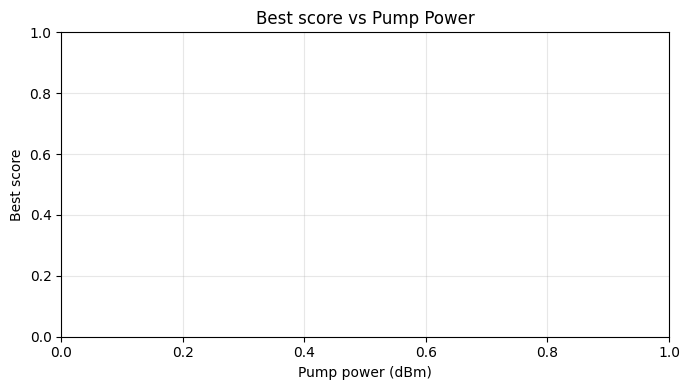


=== Best operation point per pump power ===
   Power (dBm)   pump_freq (GHz)   ifbl (µA)    score
----------------------------------------------------
         -10.0                 —           —        —
          -8.0                 —           —        —
          -6.0                 —           —        —
          -4.0                 —           —        —
          -2.0                 —           —        —
           0.0                 —           —        —
           2.0                 —           —        —
           4.0                 —           —        —
           6.0                 —           —        —
           8.0                 —           —        —
          10.0                 —           —        —
          12.0                 —           —        —
          14.0                 —           —        —
          16.0                 —           —        —
          18.0                 —           —        —
          20.0                 —      

In [37]:
results = power_sweep.analyze(reference=ref, gain_min=2, gain_median=10, f_min=6e9, f_max=8e9)